In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random
import math
from scipy import stats

# **Exercise 1 - Day 1**

### **Task 1**

##### **A**

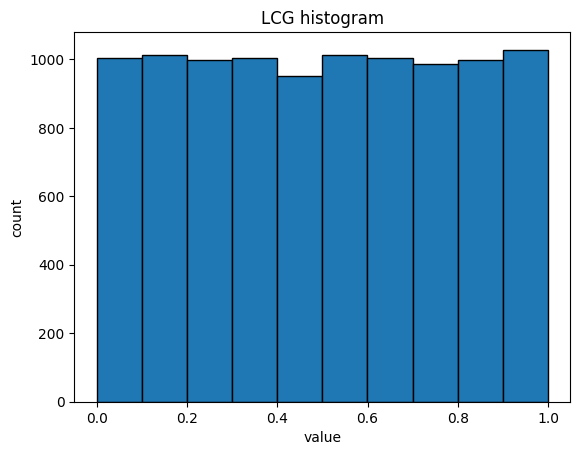

[0.17509572828086925, 0.8642896215624845, 0.7298224675518424, 0.6354865980406783, 0.23979312745536824, 0.0513203043413397, 0.2881794221492864, 0.9221741508777165, 0.9494256303147844, 0.8191357103784375]


In [2]:
def my_lcg(start_seed, mult, inc, mod, size):
    curr = start_seed
    result = []

    for _ in range(size):
        curr = (mult * curr + inc) % mod
        result.append(curr / mod)

    return result

n = 10000
A_CONST = 142
C_CONST = 14
MOD = 20109

numbers = my_lcg(start_seed=12345, mult=A_CONST, inc=C_CONST, mod=MOD, size=n)

plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("value")
plt.ylabel("count")
plt.title("LCG histogram")
plt.show()

print(numbers[:10])

##### **B**

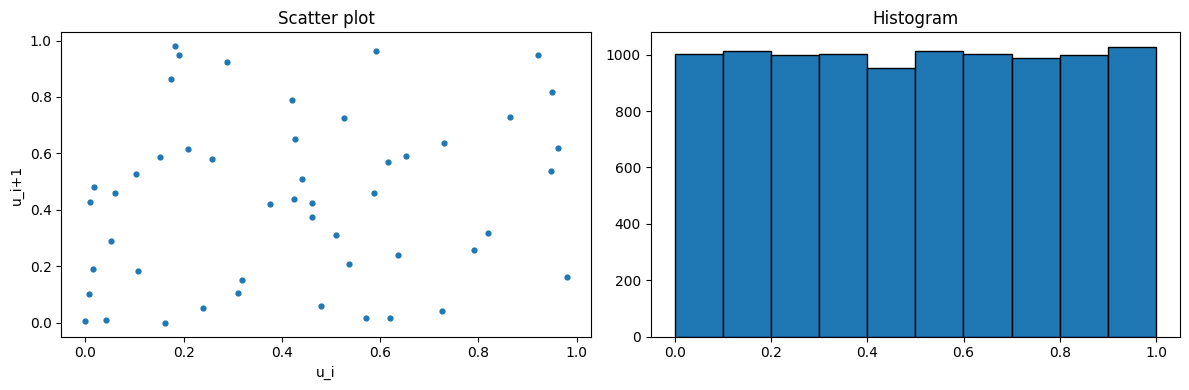

Observed counts: [1003, 1013, 999, 1003, 953, 1013, 1006, 985, 999, 1026]
Chi-square value: 3.504   Critical: 16.92
Do not reject uniformity
KS statistic: 0.00476   Critical: 0.0136
Do not reject uniformity
h = 1  correlation = 0.00945
h = 2  correlation = 0.01334
h = 3  correlation = 0.00527


In [3]:
num_bins = 10
counts = [0] * num_bins

for u in numbers:
    i = int(u * num_bins)
    if i == num_bins:
        i = num_bins - 1
    counts[i] += 1

expected = n / num_bins
chi2_val = sum((obs - expected)**2 / expected for obs in counts)

sorted_vals = sorted(numbers)
ks_stat = 0

for i in range(n):
    emp = (i + 1) / n
    diff = abs(emp - sorted_vals[i])
    if diff > ks_stat:
        ks_stat = diff

critical = 1.36 / np.sqrt(n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(numbers[:49], numbers[1:50], s=12)
ax1.set_xlabel("u_i")
ax1.set_ylabel("u_i+1")
ax1.set_title("Scatter plot")

ax2.hist(numbers, bins=10, edgecolor="black")
ax2.set_title("Histogram")

plt.tight_layout()
plt.show()

print("Observed counts:", counts)
print("Chi-square value:", round(chi2_val, 4), "  Critical: 16.92")
print("Do not reject uniformity" if chi2_val < 16.92 else "Reject uniformity")
print("KS statistic:", round(ks_stat, 5), "  Critical:", round(critical, 5))
print("Do not reject uniformity" if ks_stat < critical else "Reject uniformity")

for h in [1, 2, 3]:
    a_vals = numbers[:-h]
    b_vals = numbers[h:]
    corr = np.corrcoef(a_vals, b_vals)[0, 1]
    print(f"h = {h}  correlation = {round(corr, 5)}")


##### **C**

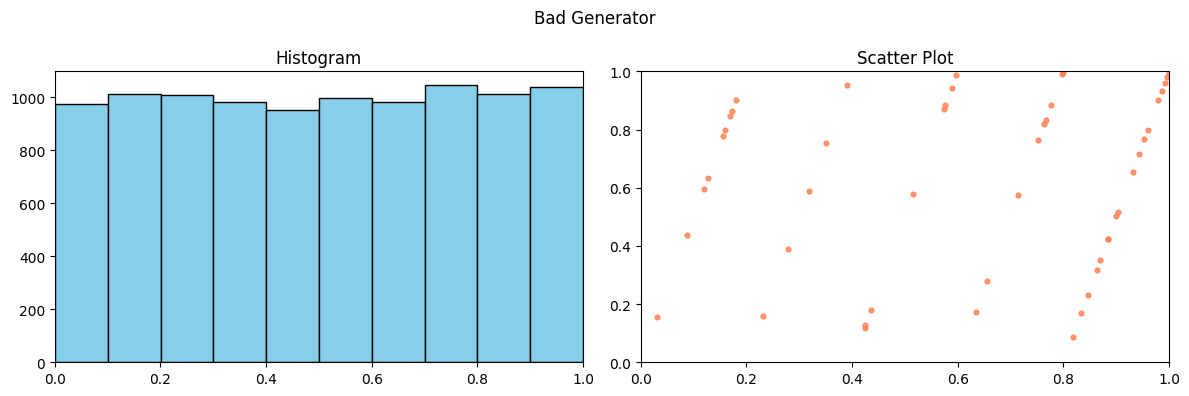

Chi-Squared: 7.892  critical: 16.92
KS: 0.01116  critical: 0.0136
h=1: correlation=0.20355
h=2: correlation=0.04263
h=3: correlation=0.00808



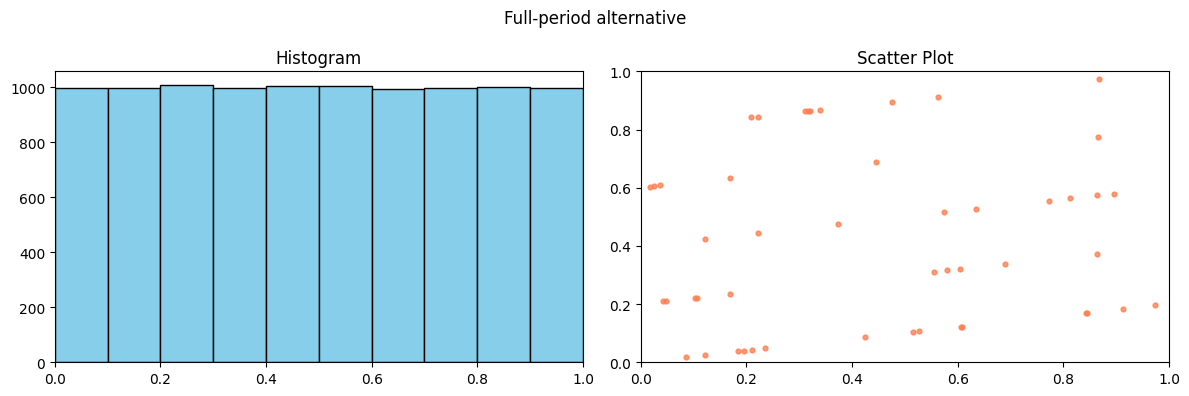

Chi-Squared: 0.192  critical: 16.92
KS: 0.00176  critical: 0.0136
h=1: correlation=0.19697
h=2: correlation=0.03442
h=3: correlation=0.00631



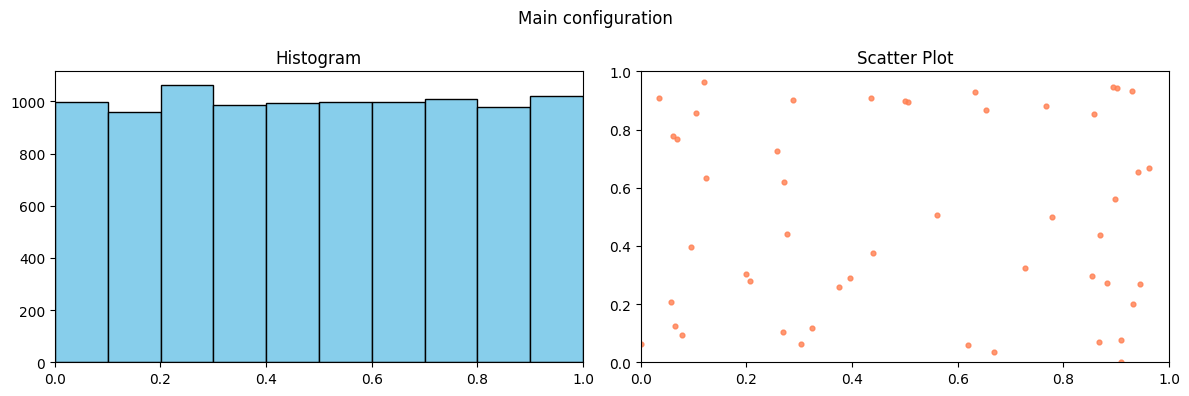

Chi-Squared: 6.488  critical: 16.92
KS: 0.00533  critical: 0.0136
h=1: correlation=-0.00101
h=2: correlation=0.00378
h=3: correlation=0.00688



In [4]:
def evaluate_generator(name, a, c, m, size=10000):
    vals = []
    x = 123

    for _ in range(size):
        x = (a * x + c) % m
        vals.append(x / m)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(name)

    ax1.hist(vals, bins=10, edgecolor="black", color="skyblue")
    ax1.set_title("Histogram")
    ax1.set_xlim(0, 1)

    ax2.scatter(vals[:49], vals[1:50], s=12, alpha=0.8, color="coral")
    ax2.set_title("Scatter Plot")
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    num_bins = 10
    counts = [0] * num_bins

    for u in vals:
        i = int(u * num_bins)
        if i == num_bins:
            i = num_bins - 1
        counts[i] += 1

    chi2_v = sum((obs - size / num_bins)**2 / (size / num_bins) for obs in counts)
    sv = sorted(vals)
    ks = max(abs((i + 1) / size - sv[i]) for i in range(size))

    print(f"Chi-Squared: {round(chi2_v, 4)}  critical: 16.92")
    print(f"KS: {round(ks, 5)}  critical: {round(1.36 / np.sqrt(size), 5)}")

    for h in [1, 2, 3]:
        corr = np.corrcoef(vals[:-h], vals[h:])[0, 1]
        print(f"h={h}: correlation={round(corr, 5)}")

    print()

evaluate_generator("Bad Generator", a=5, c=8, m=20109, size=10000)
evaluate_generator("Full-period alternative", a=1229, c=1, m=2048, size=10000)
evaluate_generator("Main configuration", a=142, c=14, m=20109, size=10000)


### **Task 2**

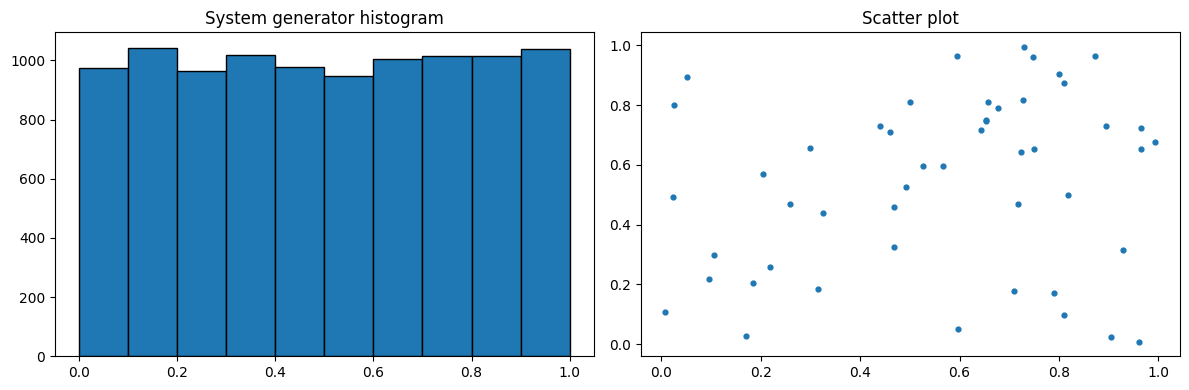

First 10: [np.float64(0.9296160928171479), np.float64(0.3163755545817859), np.float64(0.18391881167709445), np.float64(0.2045602785530397), np.float64(0.5677250290816866), np.float64(0.5955447029792516), np.float64(0.9645145197356216), np.float64(0.6531770968715709), np.float64(0.7489066375339118), np.float64(0.6535698708517353)]
Chi-square: 8.974   critical: 16.92
Do not reject uniformity
KS value: 0.00921   Critical: 0.0136
Do not reject uniformity
h = 1  correlation = 0.00366
h = 2  correlation = -0.01275
h = 5  correlation = -0.00623
h = 10  correlation = -0.00178


In [5]:
n = 10000
np.random.seed(12345)

sys_numbers = list(np.random.random(n))

num_bins = 10
counts = [0] * num_bins

for u in sys_numbers:
    i = int(u * num_bins)
    if i == num_bins:
        i = num_bins - 1
    counts[i] += 1

expected = n / num_bins
chi2_val = sum((obs - expected)**2 / expected for obs in counts)

sorted_vals = sorted(sys_numbers)
ks_stat = 0

for i in range(n):
    diff = abs((i + 1) / n - sorted_vals[i])
    if diff > ks_stat:
        ks_stat = diff

critical = 1.36 / np.sqrt(n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(sys_numbers, bins=10, edgecolor="black")
ax1.set_title("System generator histogram")

ax2.scatter(sys_numbers[:49], sys_numbers[1:50], s=12)
ax2.set_title("Scatter plot")

plt.tight_layout()
plt.show()

print("First 10:", sys_numbers[:10])
print("Chi-square:", round(chi2_val, 4), "  critical: 16.92")
print("Do not reject uniformity" if chi2_val < 16.92 else "Reject uniformity")
print("KS value:", round(ks_stat, 5), "  Critical:", round(critical, 5))
print("Do not reject uniformity" if ks_stat < critical else "Reject uniformity")

for h in [1, 2, 5, 10]:
    a_vals = sys_numbers[:-h]
    b_vals = sys_numbers[h:]
    corr = np.corrcoef(a_vals, b_vals)[0, 1]
    print(f"h = {h}  correlation = {round(corr, 5)}")


### **Task 3**

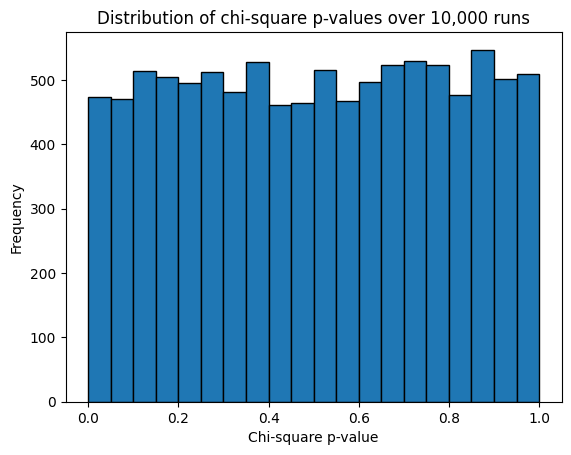

Proportion below 0.05: 0.0474


In [6]:
np.random.seed(12345)
n = 10000
repetitions = 10000
p_values = []

for _ in range(repetitions):
    vals = np.random.random(n)
    counts, _ = np.histogram(vals, bins=10, range=(0, 1))
    _, p_value = stats.chisquare(counts)
    p_values.append(p_value)

plt.hist(p_values, bins=20, edgecolor="black")
plt.xlabel("Chi-square p-value")
plt.ylabel("Frequency")
plt.title("Distribution of chi-square p-values over 10,000 runs")
plt.show()

print("Proportion below 0.05:", round(np.mean(np.array(p_values) < 0.05), 4))

# **Exercise 2 - Day 2**

### **Task 1**

p = 0.05: simulated mean = 20.2762, theoretical mean = 20.0000
       simulated variance = 384.4026, theoretical variance = 380.0000
p = 0.05  chi-square: 90.4795  critical: 125.4584
  Do not reject
p = 0.5: simulated mean = 1.9849, theoretical mean = 2.0000
       simulated variance = 1.9549, theoretical variance = 2.0000
p = 0.5  chi-square: 4.4016  critical: 16.919
  Do not reject
p = 0.95: simulated mean = 1.0504, theoretical mean = 1.0526
       simulated variance = 0.0527, theoretical variance = 0.0554
p = 0.95  chi-square: 2.4003  critical: 11.0705
  Do not reject


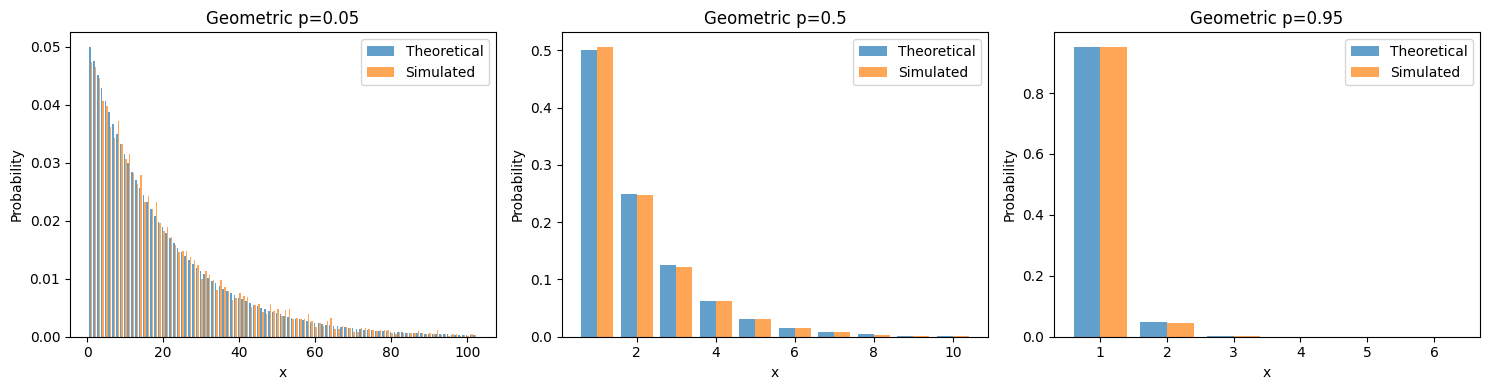

In [7]:
np.random.seed(42)
n = 10000

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, p in zip(axes, [0.05, 0.5, 0.95]):
    geom_samples = []

    for _ in range(n):
        u = np.random.random()
        x = int(np.log(u) / np.log(1 - p)) + 1
        geom_samples.append(x)

    x_vals = list(range(1, int(sum(geom_samples) / n * 5) + 2))
    simulated = [geom_samples.count(x) / n for x in x_vals]
    sim_mean = np.mean(geom_samples)
    sim_var = np.var(geom_samples, ddof=1)
    print(f"p = {p}: simulated mean = {sim_mean:.4f}, theoretical mean = {1 / p:.4f}")
    print(f"       simulated variance = {sim_var:.4f}, theoretical variance = {(1 - p) / p**2:.4f}")
    theoretical = [(1 - p)**(x - 1) * p for x in x_vals]

    ax.bar([x - 0.2 for x in x_vals], theoretical, width=0.4, label="Theoretical", alpha=0.7)
    ax.bar([x + 0.2 for x in x_vals], simulated, width=0.4, label="Simulated", alpha=0.7)
    ax.set_xlabel("x")
    ax.set_ylabel("Probability")
    ax.set_title("Geometric p=" + str(p))
    ax.legend()

    chi2_v = 0
    for x in x_vals:
        obs = geom_samples.count(x)
        exp = n * (1 - p)**(x - 1) * p
        if exp > 0:
            chi2_v += (obs - exp)**2 / exp

    critical = stats.chi2.ppf(0.95, df=len(x_vals) - 1)
    print(f"p = {p}  chi-square: {round(chi2_v, 4)}  critical: {round(critical, 4)}")
    print("  Do not reject" if chi2_v < critical else "  Reject")

plt.tight_layout()
plt.show()

### **Task 2 and 3**

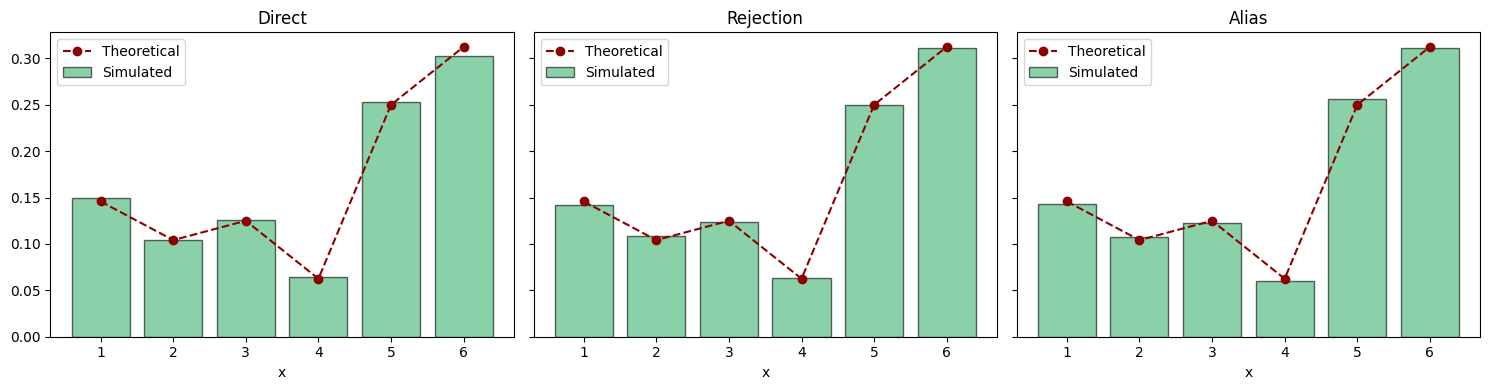

Direct - chi-square: 5.8006  p-value: 0.3261  critical: 11.0705
  Do not reject
Rejection - chi-square: 3.134  p-value: 0.6793  critical: 11.0705
  Do not reject
Alias - chi-square: 5.4954  p-value: 0.3585  critical: 11.0705
  Do not reject


In [8]:
np.random.seed(42)

probs = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]
values = [1, 2, 3, 4, 5, 6]
n = 10000

cum = []
total = 0

for p in probs:
    total += p
    cum.append(total)

direct_samples = []

for _ in range(n):
    u = np.random.random()
    for i in range(len(cum)):
        if u <= cum[i]:
            direct_samples.append(values[i])
            break

max_prob = max(probs)
rejection_samples = []

while len(rejection_samples) < n:
    u1 = np.random.random()
    idx = int(u1 * len(probs))
    u2 = np.random.random()
    if u2 <= probs[idx] / max_prob:
        rejection_samples.append(values[idx])

k = len(probs)
F = [p * k for p in probs]
L = list(range(k))
small = [i for i in range(k) if F[i] < 1]
large = [i for i in range(k) if F[i] >= 1]

while small and large:
    s = small.pop(0)
    l = large[0]
    L[s] = l
    F[l] = F[l] - (1 - F[s])
    if F[l] < 1:
        large.pop(0)
        small.append(l)

alias_samples = []

for _ in range(n):
    u1 = np.random.random()
    u2 = np.random.random()
    idx = int(u1 * k)
    if u2 <= F[idx]:
        alias_samples.append(values[idx])
    else:
        alias_samples.append(values[L[idx]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (label, sample) in zip(axes, [("Direct", direct_samples), ("Rejection", rejection_samples), ("Alias", alias_samples)]):
    sim_probs = [sample.count(v) / n for v in values]
    ax.bar(values, sim_probs, alpha=0.6, color="mediumseagreen", edgecolor="black", label="Simulated")
    ax.plot(values, probs, marker="o", color="darkred", linestyle="--", label="Theoretical")
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.legend()

plt.tight_layout()
plt.show()

for label, sample in [("Direct", direct_samples), ("Rejection", rejection_samples), ("Alias", alias_samples)]:
    chi2_v = sum((sample.count(values[i]) - n * probs[i])**2 / (n * probs[i]) for i in range(len(values)))
    critical = stats.chi2.ppf(0.95, df=len(values) - 1)
    p_value = stats.chi2.sf(chi2_v, df=len(values) - 1)
    print(f"{label} - chi-square: {round(chi2_v, 4)}  p-value: {round(p_value, 4)}  critical: {round(critical, 4)}")
    print("  Do not reject" if chi2_v < critical else "  Reject")

### **Task 4**

In [9]:
sample_size = 100000

t0 = time.time()
for _ in range(sample_size):
    u = np.random.random()
    for i in range(len(cum)):
        if u <= cum[i]:
            break
direct_time = time.time() - t0

t0 = time.time()
count = 0
while count < sample_size:
    u1 = np.random.random()
    idx = int(u1 * len(probs))
    u2 = np.random.random()
    if u2 <= probs[idx] / max_prob:
        count += 1
rejection_time = time.time() - t0

t0 = time.time()
for _ in range(sample_size):
    u1 = np.random.random()
    u2 = np.random.random()
    idx = int(u1 * k)
    if u2 > F[idx]:
        idx = L[idx]
alias_time = time.time() - t0

print("Direct time:   ", round(direct_time, 4), "s")
print("Rejection time:", round(rejection_time, 4), "s")
print("Alias time:    ", round(alias_time, 4), "s")

Direct time:    0.0325 s
Rejection time: 0.0712 s
Alias time:     0.0336 s


# **Exercise 3 - Day 2**

### **Task 1**

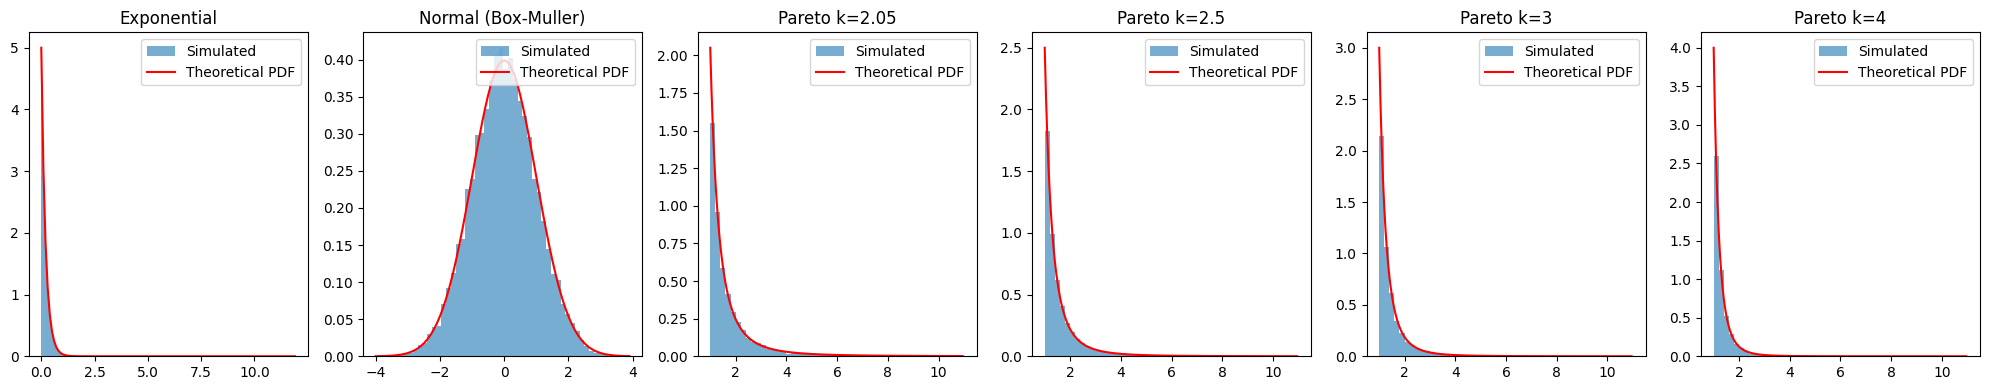

In [10]:
np.random.seed(42)
n = 10000
rate = 5
beta = 1
k_values = [2.05, 2.5, 3, 4]

exp_samples = []
for _ in range(n):
    u = np.random.random()
    exp_samples.append(-np.log(u) / rate)

def box_muller_normals(U1, U2):
    radius = np.sqrt(-2 * np.log(U1))
    angle = 2 * np.pi * U2
    return radius * np.cos(angle), radius * np.sin(angle)

U1 = np.random.uniform(0, 1, n)
U2 = np.random.uniform(0, 1, n)
Z0, Z1 = box_muller_normals(U1, U2)

fig, axes = plt.subplots(1, 2 + len(k_values), figsize=(20, 4))

x_vals = [i * 0.1 for i in range(120)]
pdf_vals = [rate * np.exp(-rate * x) for x in x_vals]
axes[0].hist(exp_samples, bins=50, density=True, alpha=0.6, label="Simulated")
axes[0].plot(x_vals, pdf_vals, "r-", label="Theoretical PDF")
axes[0].set_title("Exponential")
axes[0].legend()

x_norm = [i * 0.1 - 4 for i in range(80)]
pdf_norm = [(1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2) for x in x_norm]
axes[1].hist(list(Z0) + list(Z1), bins=50, density=True, alpha=0.6, label="Simulated")
axes[1].plot(x_norm, pdf_norm, "r-", label="Theoretical PDF")
axes[1].set_title("Normal (Box-Muller)")
axes[1].legend()

for idx, k in enumerate(k_values):
    pareto_samples = []
    for _ in range(n):
        u = np.random.random()
        pareto_samples.append(beta * u**(-1.0 / k))
    x_plot = [beta + i * 0.05 for i in range(200)]
    pdf_plot = [k * beta**k / x**(k + 1) for x in x_plot]
    axes[2 + idx].hist(pareto_samples, bins=50, density=True, alpha=0.6, range=(beta, beta + 10), label="Simulated")
    axes[2 + idx].plot(x_plot, pdf_plot, "r-", label="Theoretical PDF")
    axes[2 + idx].set_title(f"Pareto k={k}")
    axes[2 + idx].legend()

plt.tight_layout()
plt.show()

### **Task 2**

In [11]:
beta = 1
k_values = [2.05, 2.5, 3, 4]
n = 10000

print(f"{'k':<6} | {'Sim Mean':<10} | {'Theo Mean':<10} | {'Sim Var':<12} | {'Theo Var':<12}")
print("-" * 58)

for k in k_values:
    samples = []

    for _ in range(n):
        u = np.random.random()
        samples.append(beta * u**(-1.0 / k))

    sim_mean = sum(samples) / n
    theo_mean = beta * k / (k - 1)
    sim_var = sum((x - sim_mean)**2 for x in samples) / (n - 1)

    if k > 2:
        theo_var = beta**2 * k / ((k - 1)**2 * (k - 2))
        print(f"{k:<6} | {sim_mean:<10.4f} | {theo_mean:<10.4f} | {sim_var:<12.4f} | {theo_var:<12.4f}")
    else:
        print(f"{k:<6} | {sim_mean:<10.4f} | {theo_mean:<10.4f} | {sim_var:<12.4f} | {'undefined':<12}")

k      | Sim Mean   | Theo Mean  | Sim Var      | Theo Var    
----------------------------------------------------------
2.05   | 1.9436     | 1.9524     | 5.6841       | 37.1882     
2.5    | 1.6709     | 1.6667     | 1.5481       | 2.2222      
3      | 1.5090     | 1.5000     | 0.8023       | 0.7500      
4      | 1.3335     | 1.3333     | 0.2136       | 0.2222      


### **Task 3**

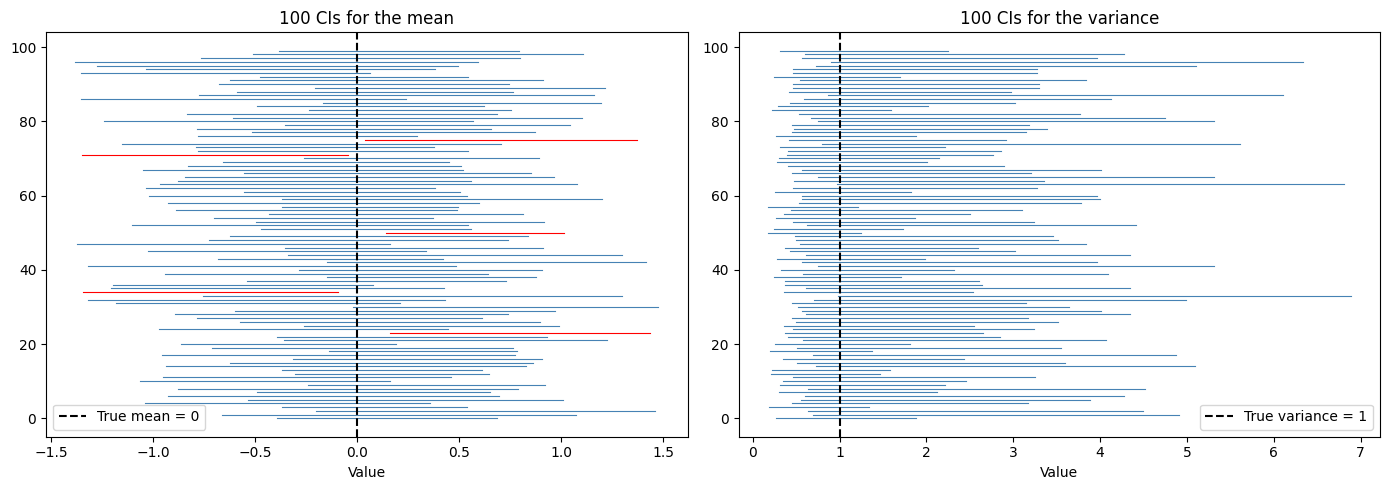

t critical value:     2.2622
chi2 lower critical:  2.7004
chi2 upper critical:  19.0228
Mean CI coverage:     0.95
Variance CI coverage: 1.0


In [12]:
mu_true = 0
sigma_true = 1
n = 10
n_intervals = 100
alpha = 0.05

t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
chi2_lo = stats.chi2.ppf(alpha / 2, df=n - 1)
chi2_hi = stats.chi2.ppf(1 - alpha / 2, df=n - 1)

np.random.seed(42)
mean_covers = 0
var_covers = 0
mean_lower_all = []
mean_upper_all = []
var_lower_all = []
var_upper_all = []

for _ in range(n_intervals):
    U1 = np.random.uniform(0, 1, n)
    U2 = np.random.uniform(0, 1, n)
    sample = [np.sqrt(-2 * np.log(U1[i])) * np.cos(2 * np.pi * U2[i]) for i in range(n)]

    sample_mean = sum(sample) / n
    sample_var = sum((x - sample_mean)**2 for x in sample) / (n - 1)
    sample_sd = sample_var**0.5

    mean_lo = sample_mean - t_crit * sample_sd / n**0.5
    mean_hi = sample_mean + t_crit * sample_sd / n**0.5
    var_lo = (n - 1) * sample_var / chi2_hi
    var_hi = (n - 1) * sample_var / chi2_lo

    mean_lower_all.append(mean_lo)
    mean_upper_all.append(mean_hi)
    var_lower_all.append(var_lo)
    var_upper_all.append(var_hi)

    if mean_lo <= mu_true <= mean_hi:
        mean_covers += 1

    if var_lo <= sigma_true**2 <= var_hi:
        var_covers += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_intervals):
    color = "steelblue" if mean_lower_all[i] <= mu_true <= mean_upper_all[i] else "red"
    ax1.plot([mean_lower_all[i], mean_upper_all[i]], [i, i], color=color, linewidth=0.8)

ax1.axvline(mu_true, color="black", linestyle="--", label="True mean = 0")
ax1.set_title("100 CIs for the mean")
ax1.set_xlabel("Value")
ax1.legend()

for i in range(n_intervals):
    color = "steelblue" if var_lower_all[i] <= sigma_true**2 <= var_upper_all[i] else "red"
    ax2.plot([var_lower_all[i], var_upper_all[i]], [i, i], color=color, linewidth=0.8)

ax2.axvline(sigma_true**2, color="black", linestyle="--", label="True variance = 1")
ax2.set_title("100 CIs for the variance")
ax2.set_xlabel("Value")
ax2.legend()

plt.tight_layout()
plt.show()

print("t critical value:    ", round(t_crit, 4))
print("chi2 lower critical: ", round(chi2_lo, 4))
print("chi2 upper critical: ", round(chi2_hi, 4))
print("Mean CI coverage:    ", mean_covers / n_intervals)
print("Variance CI coverage:", var_covers / n_intervals)

### **Task 4**

In [13]:
np.random.seed(42)
beta = 1
n = 10000
k_values = [2.05, 2.5, 3, 4]

print(f"{'k':<6} {'Method':<14} {'Sample mean':<14} {'Theory mean':<14} {'Sample variance':<18} {'Theory variance':<16} {'KS p-value':<12}")

for k in k_values:
    direct_samples = beta * np.random.random(n)**(-1.0 / k)

    y = np.random.gamma(shape=k, scale=1.0, size=n)
    composition_samples = beta + np.random.exponential(scale=beta / y)

    theory_mean = beta * k / (k - 1)
    theory_var = beta**2 * k / ((k - 1)**2 * (k - 2))

    for label, samples in [("Direct", direct_samples), ("Composition", composition_samples)]:
        ks_p = stats.kstest(samples, "pareto", args=(k, 0, beta)).pvalue
        print(f"{k:<6} {label:<14} {np.mean(samples):<14.4f} {theory_mean:<14.4f} {np.var(samples, ddof=1):<18.4f} {theory_var:<16.4f} {ks_p:<12.4f}")

k      Method         Sample mean    Theory mean    Sample variance    Theory variance  KS p-value  
2.05   Direct         1.9999         1.9524         15.4829            37.1882          0.0859      
2.05   Composition    1.8986         1.9524         4.5556             37.1882          0.2216      
2.5    Direct         1.6776         1.6667         1.8185             2.2222           0.6905      
2.5    Composition    1.6636         1.6667         1.4890             2.2222           0.3400      
3      Direct         1.5148         1.5000         0.7059             0.7500           0.0548      
3      Composition    1.4852         1.5000         0.7057             0.7500           0.3249      
4      Direct         1.3273         1.3333         0.2105             0.2222           0.5300      
4      Composition    1.3335         1.3333         0.2019             0.2222           0.4871      


# **Exercise 4 - Day 3**

### **Task 1**

In [14]:
np.random.seed(12345)
m = 10
n = 10000
reps = 10
mean_ia = 1
mean_svc = 8

results = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        now += -np.log(np.random.random()) * mean_ia
        svc = -np.log(np.random.random()) * mean_svc
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    results.append(blocked / n)

mean_b = sum(results) / reps
sd = (sum((r - mean_b)**2 for r in results) / (reps - 1))**0.5
t_crit = stats.t.ppf(0.975, df=reps - 1)
margin = t_crit * sd / reps**0.5

A = mean_svc / mean_ia
top = A**m / math.factorial(m)
bot = sum(A**i / math.factorial(i) for i in range(m + 1))
exact = top / bot

print("Blocking fractions:", results)
print("Mean:", round(mean_b, 5))
print("95% CI: (", round(mean_b - margin, 5), ",", round(mean_b + margin, 5), ")")
print("Erlang-B exact:", round(exact, 5))

Blocking fractions: [0.1147, 0.1236, 0.1232, 0.1206, 0.1179, 0.1192, 0.1126, 0.1314, 0.1154, 0.1192]
Mean: 0.11978
95% CI: ( 0.11591 , 0.12365 )
Erlang-B exact: 0.12166


### **Task 2**

##### **A**

In [15]:
np.random.seed(12345)
m = 10
n = 10000
reps = 10
mean_svc = 8

# Task 2a: Erlang-2 arrivals
res_erl2 = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        e1 = -np.log(np.random.random()) * 0.5
        e2 = -np.log(np.random.random()) * 0.5
        now += e1 + e2
        svc = -np.log(np.random.random()) * mean_svc
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    res_erl2.append(blocked / n)

mean_b = sum(res_erl2) / reps
sd = (sum((r - mean_b)**2 for r in res_erl2) / (reps - 1))**0.5
t_crit = stats.t.ppf(0.975, df=reps - 1)
margin = t_crit * sd / reps**0.5
print("Erlang-2 arrivals")
print(f"Mean: {round(mean_b, 5)} | 95% CI: [{round(mean_b - margin, 5)}, {round(mean_b + margin, 5)}]")

# Task 2a: Erlang-5 arrivals
np.random.seed(12345)
res_erl5 = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        ia = sum(-np.log(np.random.random()) * 0.2 for _ in range(5))
        now += ia
        svc = -np.log(np.random.random()) * mean_svc
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    res_erl5.append(blocked / n)

mean_b = sum(res_erl5) / reps
sd = (sum((r - mean_b)**2 for r in res_erl5) / (reps - 1))**0.5
margin = t_crit * sd / reps**0.5
print("Erlang-5 arrivals")
print(f"Mean: {round(mean_b, 5)} | 95% CI: [{round(mean_b - margin, 5)}, {round(mean_b + margin, 5)}]")

Erlang-2 arrivals
Mean: 0.09288 | 95% CI: [0.08974, 0.09602]
Erlang-5 arrivals
Mean: 0.07257 | 95% CI: [0.06995, 0.07519]


##### **B**

In [16]:
# Task 2b: Hyperexponential arrivals
np.random.seed(12345)
p1_he = 0.8; lam1_he = 0.8333
p2_he = 0.2; lam2_he = 5.0
res_he = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        selector = np.random.random()
        draw = np.random.random()
        ia = -np.log(draw) / lam1_he if selector < p1_he else -np.log(draw) / lam2_he
        now += ia
        svc = -np.log(np.random.random()) * mean_svc
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    res_he.append(blocked / n)

mean_b = sum(res_he) / reps
sd = (sum((r - mean_b)**2 for r in res_he) / (reps - 1))**0.5
margin = t_crit * sd / reps**0.5
print("Hyperexponential arrivals")
print(f"Mean: {round(mean_b, 5)} | 95% CI: [{round(mean_b - margin, 5)}, {round(mean_b + margin, 5)}]")

Hyperexponential arrivals
Mean: 0.13925 | 95% CI: [0.13402, 0.14448]


### **Task 3**

##### **A**

In [17]:
np.random.seed(12345)
m = 10
n = 10000
reps = 10
mean_ia = 1
mean_svc = 8
sigma_ln = 1.0
mu_ln = np.log(mean_svc) - sigma_ln**2 / 2
t_crit = stats.t.ppf(0.975, df=reps - 1)

# Task 3a: Constant service
res_const = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        now += -np.log(np.random.random()) * mean_ia
        svc = 8.0
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    res_const.append(blocked / n)

mean_b = sum(res_const) / reps
sd = (sum((r - mean_b)**2 for r in res_const) / (reps - 1))**0.5
margin = t_crit * sd / reps**0.5
A_ref = 8 / mean_ia
erlang_ref = (A_ref**m / math.factorial(m)) / sum(A_ref**i / math.factorial(i) for i in range(m + 1))
print(f"Constant service: Mean={round(mean_b, 5)} | 95% CI: [{round(mean_b - margin, 5)}, {round(mean_b + margin, 5)}]")
print(f"Erlang-B reference: {round(erlang_ref, 5)}")

Constant service: Mean=0.12141 | 95% CI: [0.1191, 0.12372]
Erlang-B reference: 0.12166


##### **B**

In [18]:
# Task 3b: Pareto service
for k_pareto in [1.05, 2.05]:
    np.random.seed(12345)
    xm = mean_svc * (k_pareto - 1) / k_pareto
    res_par = []

    for rep in range(reps):
        free_at = [0.0] * m
        blocked = 0
        now = 0.0

        for _ in range(n):
            now += -np.log(np.random.random()) * mean_ia
            svc = xm * np.random.random()**(-1.0 / k_pareto)
            earliest = min(free_at)
            idx = free_at.index(earliest)

            if earliest <= now:
                free_at[idx] = now + svc
            else:
                blocked += 1

        res_par.append(blocked / n)

    mean_b = sum(res_par) / reps
    sd = (sum((r - mean_b)**2 for r in res_par) / (reps - 1))**0.5
    margin = t_crit * sd / reps**0.5
    print(f"Pareto k={k_pareto}: Mean={round(mean_b, 5)} | 95% CI: [{round(mean_b - margin, 5)}, {round(mean_b + margin, 5)}]")

Pareto k=1.05: Mean=0.00132 | 95% CI: [0.00049, 0.00215]
Pareto k=2.05: Mean=0.12072 | 95% CI: [0.11539, 0.12605]


##### **C**

In [19]:
# Task 3c: Uniform service
np.random.seed(12345)
res_unif = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        now += -np.log(np.random.random()) * mean_ia
        svc = 4 + np.random.random() * 8
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    res_unif.append(blocked / n)

mean_u = sum(res_unif) / reps
sd_u = (sum((r - mean_u)**2 for r in res_unif) / (reps - 1))**0.5
mg_u = t_crit * sd_u / reps**0.5
print(f"Uniform(4,12) service: Mean={round(mean_u, 5)} | 95% CI: [{round(mean_u - mg_u, 5)}, {round(mean_u + mg_u, 5)}]")

# Gamma service
np.random.seed(12345)
res_gam = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        now += -np.log(np.random.random()) * mean_ia
        svc = -np.log(np.random.random()) * 4 + -np.log(np.random.random()) * 4
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    res_gam.append(blocked / n)

mean_g = sum(res_gam) / reps
sd_g = (sum((r - mean_g)**2 for r in res_gam) / (reps - 1))**0.5
mg_g = t_crit * sd_g / reps**0.5
print(f"Gamma(shape=2,scale=4) service: Mean={round(mean_g, 5)} | 95% CI: [{round(mean_g - mg_g, 5)}, {round(mean_g + mg_g, 5)}]")

Uniform(4,12) service: Mean=0.12116 | 95% CI: [0.11829, 0.12403]
Gamma(shape=2,scale=4) service: Mean=0.12146 | 95% CI: [0.11803, 0.12489]


##### **Lognormal**

In [20]:
# Lognormal service
np.random.seed(12345)
res_ln = []

for rep in range(reps):
    free_at = [0.0] * m
    blocked = 0
    now = 0.0

    for _ in range(n):
        now += -np.log(np.random.random()) * mean_ia
        u1 = np.random.random()
        u2 = np.random.random()
        z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
        svc = np.exp(mu_ln + sigma_ln * z)
        earliest = min(free_at)
        idx = free_at.index(earliest)

        if earliest <= now:
            free_at[idx] = now + svc
        else:
            blocked += 1

    res_ln.append(blocked / n)

mean_b = sum(res_ln) / reps
sd = (sum((r - mean_b)**2 for r in res_ln) / (reps - 1))**0.5
margin = t_crit * sd / reps**0.5
print(f"Lognormal(sigma=1) service: Mean={round(mean_b, 5)} | 95% CI: [{round(mean_b - margin, 5)}, {round(mean_b + margin, 5)}]")

Lognormal(sigma=1) service: Mean=0.12275 | 95% CI: [0.11756, 0.12794]


### **Task 5**

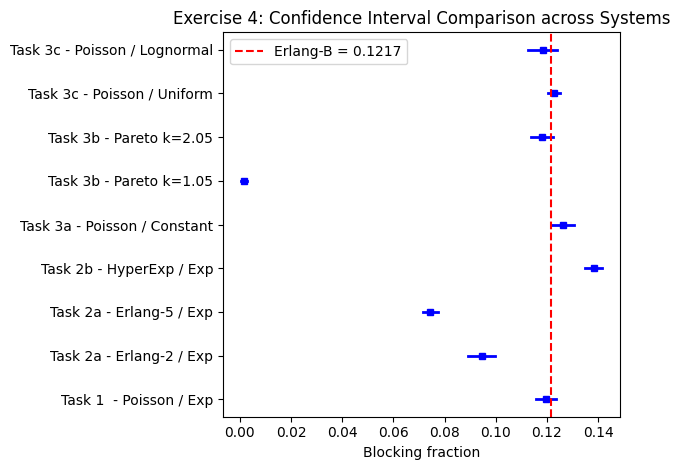

Scenario                                     Mean    Lower    Upper    Width
----------------------------------------------------------------------------
Task 1  - Poisson / Exp                   0.11978  0.11591  0.12365  0.00773
Task 2a - Erlang-2 / Exp                  0.09445  0.08926  0.09964  0.01038
Task 2a - Erlang-5 / Exp                  0.07445  0.07137  0.07753  0.00615
Task 2b - HyperExp / Exp                  0.13825  0.13498  0.14152  0.00653
Task 3a - Poisson / Constant              0.12619  0.12160  0.13078  0.00919
Task 3b - Pareto k=1.05                   0.00153  0.00043  0.00263  0.00220
Task 3b - Pareto k=2.05                   0.11798  0.11360  0.12236  0.00876
Task 3c - Poisson / Uniform               0.12290  0.12061  0.12519  0.00459
Task 3c - Poisson / Lognormal             0.11828  0.11277  0.12379  0.01103

Erlang-B exact: 0.12166


In [21]:
np.random.seed(12345)
m = 10
n = 10000
reps = 10
mean_ia = 1
mean_svc = 8
t_crit = stats.t.ppf(0.975, df=reps - 1)
mu_ln_summary = np.log(mean_svc) - 0.5
p1_s = 0.8; lam1_s = 0.8333; lam2_s = 5.0

def run_scenario(get_ia, get_svc):
    res = []

    for _ in range(reps):
        free_at = [0.0] * m
        blocked = 0
        now = 0.0

        for _ in range(n):
            now += get_ia()
            svc = get_svc()
            earliest = min(free_at)
            idx_s = free_at.index(earliest)

            if earliest <= now:
                free_at[idx_s] = now + svc
            else:
                blocked += 1

        res.append(blocked / n)

    mu = sum(res) / reps
    sd = (sum((r - mu)**2 for r in res) / (reps - 1))**0.5
    margin = t_crit * sd / reps**0.5
    return mu, mu - margin, mu + margin

scenarios = [
    ("Task 1  - Poisson / Exp",      lambda: -np.log(np.random.random()) * mean_ia,  lambda: -np.log(np.random.random()) * mean_svc),
    ("Task 2a - Erlang-2 / Exp",     lambda: -np.log(np.random.random()) * 0.5 + -np.log(np.random.random()) * 0.5, lambda: -np.log(np.random.random()) * mean_svc),
    ("Task 2a - Erlang-5 / Exp",     lambda: sum(-np.log(np.random.random()) * 0.2 for _ in range(5)), lambda: -np.log(np.random.random()) * mean_svc),
    ("Task 2b - HyperExp / Exp",     lambda: -np.log(np.random.random()) / lam1_s if np.random.random() < p1_s else -np.log(np.random.random()) / lam2_s, lambda: -np.log(np.random.random()) * mean_svc),
    ("Task 3a - Poisson / Constant", lambda: -np.log(np.random.random()) * mean_ia,  lambda: mean_svc),
    ("Task 3b - Pareto k=1.05",      lambda: -np.log(np.random.random()) * mean_ia,  lambda: mean_svc * (1.05 - 1) / 1.05 * np.random.random()**(-1.0 / 1.05)),
    ("Task 3b - Pareto k=2.05",      lambda: -np.log(np.random.random()) * mean_ia,  lambda: mean_svc * (2.05 - 1) / 2.05 * np.random.random()**(-1.0 / 2.05)),
    ("Task 3c - Poisson / Uniform",  lambda: -np.log(np.random.random()) * mean_ia,  lambda: 4 + np.random.random() * 8),
    ("Task 3c - Poisson / Lognormal",lambda: -np.log(np.random.random()) * mean_ia,  lambda: np.random.lognormal(mean=mu_ln_summary, sigma=1.0)),
]

all_results = []

for label, get_ia, get_svc in scenarios:
    mean_b, lo, hi = run_scenario(get_ia, get_svc)
    all_results.append((label, mean_b, lo, hi))

A_val = mean_svc / mean_ia
erlang_exact = (A_val**m / math.factorial(m)) / sum(A_val**i / math.factorial(i) for i in range(m + 1))

for i, (label, mean_b, lo, hi) in enumerate(all_results):
    plt.plot([lo, hi], [i, i], "b-", linewidth=2)
    plt.plot(mean_b, i, "bs", markersize=5)

plt.axvline(erlang_exact, color="red", linestyle="--", label=f"Erlang-B = {round(erlang_exact, 4)}")
plt.yticks(range(len(all_results)), [r[0] for r in all_results])
plt.xlabel("Blocking fraction")
plt.title("Exercise 4: Confidence Interval Comparison across Systems")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{'Scenario':<40} {'Mean':>8} {'Lower':>8} {'Upper':>8} {'Width':>8}")
print("-" * 76)
for label, mean_b, lo, hi in all_results:
    print(f"{label:<40} {mean_b:>8.5f} {lo:>8.5f} {hi:>8.5f} {hi - lo:>8.5f}")
print(f"\nErlang-B exact: {round(erlang_exact, 5)}")

# **Exercise 5 - Day 4**

### **Task 1**

##### **A**

In [22]:
np.random.seed(42)
sample_n = 100
U_vals = np.random.uniform(0, 1, sample_n)
X_vals = np.exp(U_vals)

##### **B**

In [23]:
alpha = 0.05
z_score = stats.norm.ppf(1 - alpha / 2)

theta_hat = sum(X_vals) / sample_n
s_crude = (sum((x - theta_hat)**2 for x in X_vals) / (sample_n - 1))**0.5

ci_lo = theta_hat - z_score * s_crude / sample_n**0.5
ci_hi = theta_hat + z_score * s_crude / sample_n**0.5

print("Point estimate:", round(theta_hat, 4))
print(f"95% CI: ({round(ci_lo, 4)}, {round(ci_hi, 4)})")

Point estimate: 1.6721
95% CI: (1.574, 1.7701)


### **Task 2**

In [24]:
f_direct = np.exp(U_vals)
f_antithetic = np.exp(1 - U_vals)
Y_anti = (f_direct + f_antithetic) / 2

theta_anti = sum(Y_anti) / len(Y_anti)
s_anti = (sum((y - theta_anti)**2 for y in Y_anti) / (len(Y_anti) - 1))**0.5

ci_lo_a = theta_anti - z_score * s_anti / len(Y_anti)**0.5
ci_hi_a = theta_anti + z_score * s_anti / len(Y_anti)**0.5

print("Mean:", round(theta_anti, 4))
print(f"95% CI: ({round(ci_lo_a, 4)}, {round(ci_hi_a, 4)})")

Mean: 1.7226
95% CI: (1.7103, 1.7349)


### **Task 3**

In [25]:
Z_ctrl = U_vals
mu_Z = 0.5

cov_xz = sum((X_vals[i] - theta_hat) * (Z_ctrl[i] - mu_Z) for i in range(sample_n)) / sample_n
var_z = sum((z - mu_Z)**2 for z in Z_ctrl) / (sample_n - 1)
c_opt = -cov_xz / var_z

Y_cv = np.array([X_vals[i] + c_opt * (Z_ctrl[i] - mu_Z) for i in range(sample_n)])
theta_cv = sum(Y_cv) / sample_n

s_cv = (sum((y - theta_cv)**2 for y in Y_cv) / (sample_n - 1))**0.5
ci_lo_c = theta_cv - z_score * s_cv / sample_n**0.5
ci_hi_c = theta_cv + z_score * s_cv / sample_n**0.5

print("Point estimate:", round(theta_cv, 4))
print("c:", round(c_opt, 4))
print(f"95% CI: ({round(ci_lo_c, 4)}, {round(ci_hi_c, 4)})")
print("Variance:", round(float(np.var(Y_cv)), 6))

Point estimate: 1.7208
c: -1.6349
95% CI: (1.7085, 1.7331)
Variance: 0.003918


### **Task 4**

In [26]:
strata_k = 10
rep_n = 100

Y_strat = []

for i in range(rep_n):
    strat_u = (np.arange(strata_k) + np.random.uniform(0, 1, strata_k)) / strata_k
    Y_strat.append(np.mean(np.exp(strat_u)))

Y_strat = np.array(Y_strat)
theta_ss = sum(Y_strat) / rep_n

s_ss = (sum((y - theta_ss)**2 for y in Y_strat) / (rep_n - 1))**0.5
ci_lo_s = theta_ss - z_score * s_ss / rep_n**0.5
ci_hi_s = theta_ss + z_score * s_ss / rep_n**0.5

print("Point estimate:", round(theta_ss, 4))
print(f"95% CI: ({round(ci_lo_s, 4)}, {round(ci_hi_s, 4)})")

Point estimate: 1.7176
95% CI: (1.7142, 1.721)


### **Task 5**

In [27]:
m_sys = 10
svc_mean = 8
ia_mean = 1
sim_n = 10000
rep_count = 10
np.random.seed(42)

block_vals = []
avg_svc_list = []

for _ in range(rep_count):
    free_at = [0.0] * m_sys
    blocked = 0
    now = 0.0
    total_svc = 0.0
    served = 0

    for _ in range(sim_n):
        now += -np.log(np.random.random()) * ia_mean
        svc = -np.log(np.random.random()) * svc_mean
        earliest = min(free_at)
        idx_b = free_at.index(earliest)

        if earliest <= now:
            free_at[idx_b] = now + svc
            total_svc += svc
            served += 1
        else:
            blocked += 1

    block_vals.append(blocked / sim_n)
    avg_svc_list.append(total_svc / served)

X_blk = np.array(block_vals)
Z_blk = np.array(avg_svc_list)

cov_bz = np.mean(X_blk * Z_blk) - np.mean(X_blk) * np.mean(Z_blk)
var_bz = sum((z - np.mean(Z_blk))**2 for z in Z_blk) / (rep_count - 1)
c_blk = -cov_bz / var_bz

Y_blk_cv = X_blk + c_blk * (Z_blk - svc_mean)
mu_cv = np.mean(Y_blk_cv)
s_cv_b = np.std(Y_blk_cv, ddof=1)
t_cr = stats.t.ppf(0.975, df=rep_count - 1)
mg = t_cr * s_cv_b / rep_count**0.5

s_plain = np.std(X_blk, ddof=1)
margin_plain = t_cr * s_plain / rep_count**0.5

print("Point estimate:", round(mu_cv, 5))
print("95% CI: (", round(mu_cv - mg, 5), ",", round(mu_cv + mg, 5), ")")
print("CI width without control variates:", round(2 * margin_plain, 5))
print("CI width with control variates:   ", round(2 * mg, 5))

Point estimate: 0.12343
95% CI: ( 0.1202 , 0.12667 )
CI width without control variates: 0.01161
CI width with control variates:    0.00647


### **Task 6**

### **Task 7**

In [28]:
np.random.seed(42)
num_is = 10000
a_threshold = 2

Z_crude = np.random.normal(0, 1, num_is)
p_crude = sum(1 for z in Z_crude if z > a_threshold) / num_is

def importance_sampling_est(threshold, var_is, num_samples):
    sd_is = var_is**0.5
    Y_is = np.random.normal(threshold, sd_is, num_samples)
    f_vals = stats.norm.pdf(Y_is, 0, 1)
    g_vals = stats.norm.pdf(Y_is, threshold, sd_is)
    w = (Y_is > threshold) * f_vals / g_vals
    return float(np.mean(w))

print("Crude estimate:", round(p_crude, 6))
print("True value:    ", round(stats.norm.sf(a_threshold), 6))

for threshold in [2, 3, 4, 5]:
    est_is = importance_sampling_est(threshold, var_is=1.0, num_samples=1000)
    true_val = stats.norm.sf(threshold)
    print("a =", threshold, "  IS =", round(est_is, 6), "  true =", round(true_val, 6))

for num_s in [100, 500, 1000, 5000, 10000]:
    est_is = importance_sampling_est(threshold=3, var_is=1.0, num_samples=num_s)
    print("n =", num_s, "  IS =", round(est_is, 6), "  true =", round(stats.norm.sf(3), 6))

for var_s in [0.5, 1.0, 2.0, 5.0]:
    est_is = importance_sampling_est(threshold=3, var_is=var_s, num_samples=1000)
    print("sigma2 =", var_s, "  IS =", round(est_is, 6), "  true =", round(stats.norm.sf(3), 6))

Crude estimate: 0.0237
True value:     0.02275
a = 2   IS = 0.022937   true = 0.02275
a = 3   IS = 0.001347   true = 0.00135
a = 4   IS = 3.2e-05   true = 3.2e-05
a = 5   IS = 0.0   true = 0.0
n = 100   IS = 0.000509   true = 0.00135
n = 500   IS = 0.001336   true = 0.00135
n = 1000   IS = 0.001361   true = 0.00135
n = 5000   IS = 0.001405   true = 0.00135
n = 10000   IS = 0.001372   true = 0.00135
sigma2 = 0.5   IS = 0.001269   true = 0.00135
sigma2 = 1.0   IS = 0.001439   true = 0.00135
sigma2 = 2.0   IS = 0.001171   true = 0.00135
sigma2 = 5.0   IS = 0.001141   true = 0.00135


### **Task 8**

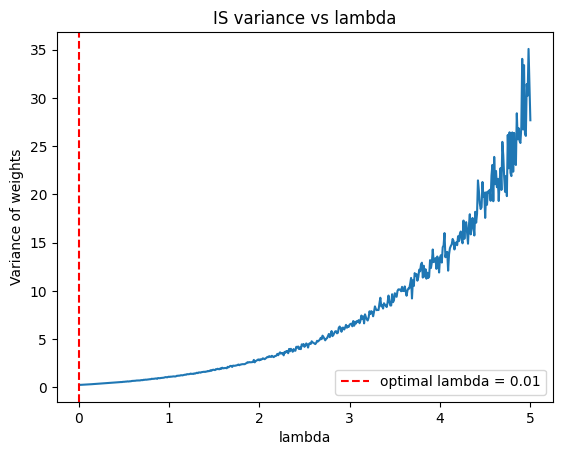

Optimal lambda: 0.01
  lambda    estimate      variance
   0.500    1.708755    0.56066698
   1.000    1.723156    1.07956696
   2.000    1.701858    2.79234869
   3.000    1.726864    6.38056647
   0.010    1.719703    0.24582503
True value: 1.718282


In [29]:
def weighted_estimate(lam_val, num_pts):
    U_pts = np.random.uniform(0, 1, num_pts)
    Y_pts = -1 / lam_val * np.log(1 - U_pts * (1 - np.exp(-lam_val)))
    g_pts = lam_val * np.exp(-lam_val * Y_pts) / (1 - np.exp(-lam_val))
    wts = np.exp(Y_pts) / g_pts
    return float(np.mean(wts)), float(np.var(wts))

lam_grid = np.linspace(0.01, 5, 500)
var_grid = [weighted_estimate(lv, num_pts=10000)[1] for lv in lam_grid]
best_lam = lam_grid[int(np.argmin(var_grid))]

plt.plot(lam_grid, var_grid)
plt.axvline(best_lam, color="r", linestyle="--", label="optimal lambda = " + str(round(best_lam, 2)))
plt.xlabel("lambda")
plt.ylabel("Variance of weights")
plt.title("IS variance vs lambda")
plt.legend()
plt.show()

print("Optimal lambda:", round(best_lam, 3))
print(f"{'lambda':>8}  {'estimate':>10}  {'variance':>12}")

for lv in [0.5, 1.0, 2.0, 3.0, best_lam]:
    est_v, var_v = weighted_estimate(lv, num_pts=10000)
    print(f"{lv:>8.3f}  {est_v:>10.6f}  {var_v:>12.8f}")

print("True value:", round(np.e - 1, 6))

### **Task 9**

# **Exercise 6 - Day 5**

### **Task 1**

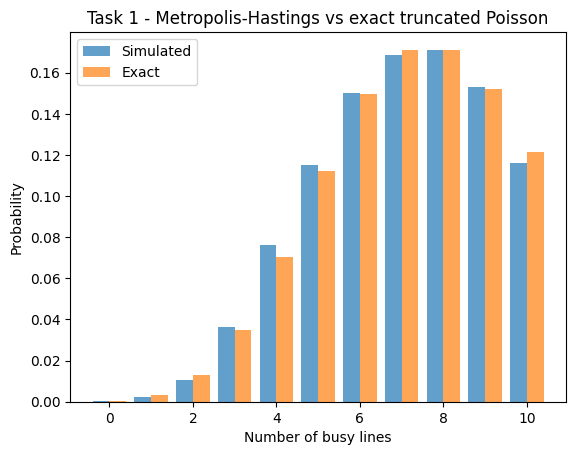

 State   Observed   Expected
------------------------------
     0          4       4.11
     1         22      32.89
     2        105     131.57
     3        361     350.86
     4        762     701.72
     5       1151    1122.75
     6       1503     1497.0
     7       1686    1710.86
     8       1712    1710.86
     9       1531    1520.76
    10       1163    1216.61
Chi-square statistic: 17.9765
Critical value (df=10, 0.95): 18.307
Do not reject: samples match truncated Poisson distribution


In [30]:
np.random.seed(42)
A_mh = 8
m_mh = 10
n_mh = 10000
burn = 1000

def g_mh(i):
    if i < 0 or i > m_mh:
        return 0.0
    val = 1.0
    for ki in range(1, i + 1):
        val *= A_mh / ki
    return val

state_mh = 0
chain_mh = []

for _ in range(n_mh + burn):
    move = 1 if np.random.random() < 0.5 else -1
    proposal = state_mh + move

    if proposal < 0 or proposal > m_mh:
        accept_prob = 0.0
    else:
        accept_prob = min(1.0, g_mh(proposal) / g_mh(state_mh))

    if np.random.random() < accept_prob:
        state_mh = proposal

    chain_mh.append(state_mh)

chain_mh = chain_mh[burn:]

norm_const = sum(g_mh(i) for i in range(m_mh + 1))
exact_dist = [g_mh(i) / norm_const for i in range(m_mh + 1)]
obs_counts = [chain_mh.count(i) for i in range(m_mh + 1)]

x_range = list(range(m_mh + 1))
plt.bar([x - 0.2 for x in x_range], [o / n_mh for o in obs_counts], width=0.4, label="Simulated", alpha=0.7)
plt.bar([x + 0.2 for x in x_range], exact_dist, width=0.4, label="Exact", alpha=0.7)
plt.xlabel("Number of busy lines")
plt.ylabel("Probability")
plt.title("Task 1 - Metropolis-Hastings vs exact truncated Poisson")
plt.legend()
plt.show()

chi2_mh = sum((obs_counts[i] - exact_dist[i] * n_mh)**2 / (exact_dist[i] * n_mh) for i in range(m_mh + 1))
df_mh = m_mh
crit_mh = stats.chi2.ppf(0.95, df=df_mh)

print(f"{'State':>6} {'Observed':>10} {'Expected':>10}")
print("-" * 30)
for i in range(m_mh + 1):
    print(f"{i:>6} {obs_counts[i]:>10} {round(exact_dist[i] * n_mh, 2):>10}")

print("Chi-square statistic:", round(chi2_mh, 4))
print("Critical value (df=" + str(df_mh) + ", 0.95):", round(crit_mh, 4))
print("Do not reject: samples match truncated Poisson distribution" if chi2_mh < crit_mh else "Reject: samples do not match")

### **Task 2**

##### **A**

In [31]:
np.random.seed(42)
A1_2d = 4
A2_2d = 4
m_2d = 10
n_2d = 20000
burn_2d = 2000

def g2d(i, j):
    if i < 0 or j < 0 or i + j > m_2d:
        return 0.0
    vi = 1.0
    for ki in range(1, i + 1):
        vi *= A1_2d / ki
    vj = 1.0
    for kj in range(1, j + 1):
        vj *= A2_2d / kj
    return vi * vj

directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]
si_2d, sj_2d = 0, 0
samples_2d = []

for _ in range(n_2d + burn_2d):
    di, dj = directions[int(np.random.random() * 4)]
    pi_2d, pj_2d = si_2d + di, sj_2d + dj
    g_cur = g2d(si_2d, sj_2d)
    g_prop = g2d(pi_2d, pj_2d)
    alpha_2d = 1.0 if g_cur == 0.0 else min(1.0, g_prop / g_cur)

    if np.random.random() < alpha_2d:
        si_2d, sj_2d = pi_2d, pj_2d

    samples_2d.append((si_2d, sj_2d))

samples_2d = samples_2d[burn_2d:]
total_2d = sum(g2d(i, j) for i in range(m_2d + 1) for j in range(m_2d + 1) if i + j <= m_2d)
states_2d = [(i, j) for i in range(m_2d + 1) for j in range(m_2d + 1) if i + j <= m_2d]
obs_2d = {}

for s in samples_2d:
    obs_2d[s] = obs_2d.get(s, 0) + 1

chi2_2d = sum((obs_2d.get(st, 0) - g2d(*st) / total_2d * n_2d)**2 / (g2d(*st) / total_2d * n_2d) for st in states_2d if g2d(*st) > 0)
df_2d = len(states_2d) - 1
crit_2d = stats.chi2.ppf(0.95, df=df_2d)
print("Direct MH chi-square:", round(chi2_2d, 4))
print("Critical value (df=" + str(df_2d) + "):", round(crit_2d, 4))
print("Do not reject: good fit" if chi2_2d < crit_2d else "Reject")

Direct MH chi-square: 423.3448
Critical value (df=65): 84.8206
Reject


##### **B**

In [32]:
np.random.seed(42)
si_cw, sj_cw = 0, 0
samples_cw = []

for _ in range(n_2d + burn_2d):
    if np.random.random() < 0.5:
        step_i = 1 if np.random.random() < 0.5 else -1
        pi_cw, pj_cw = si_cw + step_i, sj_cw
    else:
        step_j = 1 if np.random.random() < 0.5 else -1
        pi_cw, pj_cw = si_cw, sj_cw + step_j

    g_c = g2d(si_cw, sj_cw)
    g_p = g2d(pi_cw, pj_cw)
    alpha_cw = 1.0 if g_c == 0.0 else min(1.0, g_p / g_c)

    if np.random.random() < alpha_cw:
        si_cw, sj_cw = pi_cw, pj_cw

    samples_cw.append((si_cw, sj_cw))

samples_cw = samples_cw[burn_2d:]
obs_cw = {}

for s in samples_cw:
    obs_cw[s] = obs_cw.get(s, 0) + 1

chi2_cw = sum((obs_cw.get(st, 0) - g2d(*st) / total_2d * n_2d)**2 / (g2d(*st) / total_2d * n_2d) for st in states_2d if g2d(*st) > 0)
print("Coordinatewise MH chi-square:", round(chi2_cw, 4))
print("Do not reject: good fit" if chi2_cw < crit_2d else "Reject")

Coordinatewise MH chi-square: 189.965
Reject


##### **C**

In [33]:
np.random.seed(42)
si_gb, sj_gb = 0, 0
samples_gb = []

for _ in range(n_2d + burn_2d):
    if np.random.random() < 0.5:
        max_i_gb = m_2d - sj_gb
        w_i = [g2d(ii, sj_gb) for ii in range(max_i_gb + 1)]
        tot_i = sum(w_i)
        pr_i = [w / tot_i for w in w_i]
        u_gb = np.random.random()
        cum = 0.0
        for ii, p_gb in enumerate(pr_i):
            cum += p_gb
            if u_gb < cum:
                si_gb = ii
                break
    else:
        max_j_gb = m_2d - si_gb
        w_j = [g2d(si_gb, jj) for jj in range(max_j_gb + 1)]
        tot_j = sum(w_j)
        pr_j = [w / tot_j for w in w_j]
        u_gb = np.random.random()
        cum = 0.0
        for jj, p_gb in enumerate(pr_j):
            cum += p_gb
            if u_gb < cum:
                sj_gb = jj
                break

    samples_gb.append((si_gb, sj_gb))

samples_gb = samples_gb[burn_2d:]
obs_gb = {}

for s in samples_gb:
    obs_gb[s] = obs_gb.get(s, 0) + 1

chi2_gb = sum((obs_gb.get(st, 0) - g2d(*st) / total_2d * n_2d)**2 / (g2d(*st) / total_2d * n_2d) for st in states_2d if g2d(*st) > 0)
print("Gibbs sampling chi-square:", round(chi2_gb, 4))
print("Do not reject: good fit" if chi2_gb < crit_2d else "Reject")

Gibbs sampling chi-square: 124.3526
Reject


### **Task 3**

##### **A**

In [34]:
np.random.seed(42)
rho_prior = 0.5

u1p = np.random.random(); u2p = np.random.random()
z1p = np.sqrt(-2 * np.log(u1p)) * np.cos(2 * np.pi * u2p)
u3p = np.random.random(); u4p = np.random.random()
z2_ind_p = np.sqrt(-2 * np.log(u3p)) * np.cos(2 * np.pi * u4p)
z2p = rho_prior * z1p + np.sqrt(1 - rho_prior**2) * z2_ind_p

xi_val = z1p
gamma_val = z2p
theta_true = np.exp(xi_val)
psi_true = np.exp(gamma_val)

##### **B**

In [35]:
n_obs_b = 10
X_obs_b = []

for _ in range(n_obs_b):
    u1o = np.random.random(); u2o = np.random.random()
    z_obs = np.sqrt(-2 * np.log(u1o)) * np.cos(2 * np.pi * u2o)
    X_obs_b.append(theta_true + np.sqrt(psi_true) * z_obs)

##### **C**

In [36]:
xbar_b = sum(X_obs_b) / n_obs_b
s2_b = sum((x - xbar_b)**2 for x in X_obs_b) / n_obs_b

def log_prior_fn(th, ps):
    if th <= 0 or ps <= 0:
        return -np.inf
    lx = np.log(th); ly = np.log(ps)
    return -1 / (2 * (1 - rho_prior**2)) * (lx**2 - 2 * rho_prior * lx * ly + ly**2) - lx - ly

def log_likelihood_fn(th, ps):
    if th <= 0 or ps <= 0:
        return -np.inf
    return -n_obs_b / 2 * np.log(ps) - n_obs_b / (2 * ps) * (s2_b + (xbar_b - th)**2)

def log_posterior_fn(th, ps):
    return log_prior_fn(th, ps) + log_likelihood_fn(th, ps)

##### **D**

In [37]:
np.random.seed(42)
n_mcmc_d = 20000
burn_mcmc_d = 2000
step_d = 0.3
th_d = 1.0
ps_d = 1.0
th_chain = []
ps_chain = []

for _ in range(n_mcmc_d + burn_mcmc_d):
    u1m = np.random.random(); u2m = np.random.random()
    z1m = np.sqrt(-2 * np.log(u1m)) * np.cos(2 * np.pi * u2m)
    u3m = np.random.random(); u4m = np.random.random()
    z2m = np.sqrt(-2 * np.log(u3m)) * np.cos(2 * np.pi * u4m)
    th_prop_d = th_d * np.exp(step_d * z1m)
    ps_prop_d = ps_d * np.exp(step_d * z2m)
    log_a_d = (log_posterior_fn(th_prop_d, ps_prop_d) - log_posterior_fn(th_d, ps_d)
               + np.log(th_prop_d) + np.log(ps_prop_d) - np.log(th_d) - np.log(ps_d))

    if np.log(np.random.random()) < log_a_d:
        th_d = th_prop_d
        ps_d = ps_prop_d

    th_chain.append(th_d)
    ps_chain.append(ps_d)

th_chain = th_chain[burn_mcmc_d:]
ps_chain = ps_chain[burn_mcmc_d:]

##### **E**

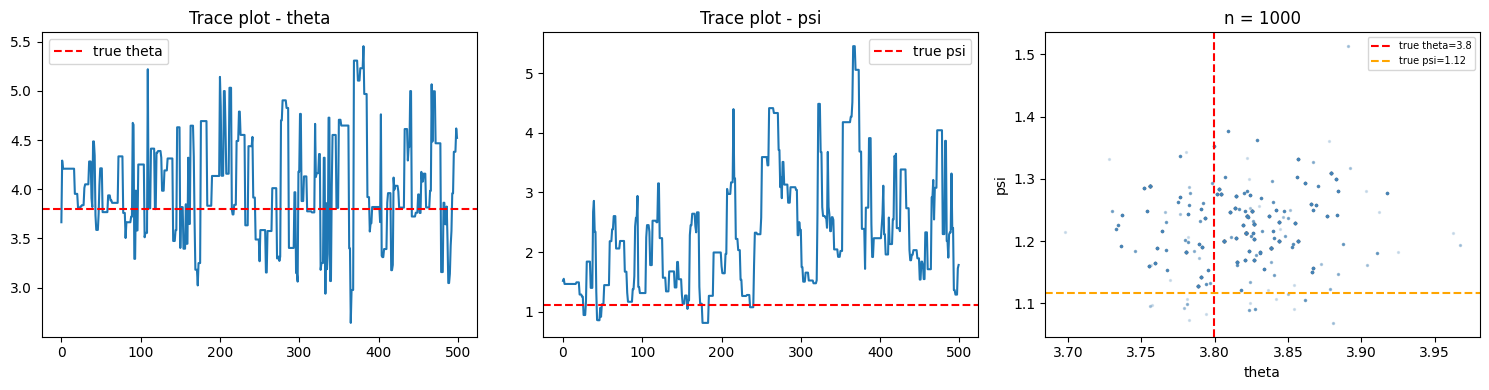

xi:    1.3348
gamma: 0.1106
theta: 3.7993
psi:   1.1169
Observations: [np.float64(4.9338), np.float64(5.4806), np.float64(3.5216), np.float64(6.6921), np.float64(3.9493), np.float64(4.5922), np.float64(2.1886), np.float64(3.4485), np.float64(4.4696), np.float64(2.6922)]
Sample mean:  4.1968
Posterior mean theta: 4.0697
Posterior mean psi:   2.1324
True theta: 3.7993   True psi: 1.1169


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(th_chain[:500])
axes[0].axhline(theta_true, color="red", linestyle="--", label="true theta")
axes[0].set_title("Trace plot - theta")
axes[0].legend()

axes[1].plot(ps_chain[:500])
axes[1].axhline(psi_true, color="red", linestyle="--", label="true psi")
axes[1].set_title("Trace plot - psi")
axes[1].legend()

for n_obs_e, ax_e in zip([10, 100, 1000], [None, None, axes[2]]):
    np.random.seed(42)
    X_e = [theta_true + np.sqrt(psi_true) * np.sqrt(-2 * np.log(np.random.random())) * np.cos(2 * np.pi * np.random.random()) for _ in range(n_obs_e)]
    xbar_e = sum(X_e) / n_obs_e
    s2_e = sum((x - xbar_e)**2 for x in X_e) / n_obs_e

    def log_lik_e(th, ps):
        if th <= 0 or ps <= 0:
            return -np.inf
        return -n_obs_e / 2 * np.log(ps) - n_obs_e / (2 * ps) * (s2_e + (xbar_e - th)**2)

    th_e, ps_e = 1.0, 1.0
    th_ep, ps_ep = [], []

    for _ in range(n_mcmc_d + burn_mcmc_d):
        z1e = np.sqrt(-2 * np.log(np.random.random())) * np.cos(2 * np.pi * np.random.random())
        z2e = np.sqrt(-2 * np.log(np.random.random())) * np.cos(2 * np.pi * np.random.random())
        th_pe = th_e * np.exp(step_d * z1e)
        ps_pe = ps_e * np.exp(step_d * z2e)
        log_ae = (log_prior_fn(th_pe, ps_pe) + log_lik_e(th_pe, ps_pe)
                  - log_prior_fn(th_e, ps_e) - log_lik_e(th_e, ps_e)
                  + np.log(th_pe) + np.log(ps_pe) - np.log(th_e) - np.log(ps_e))

        if np.log(np.random.random()) < log_ae:
            th_e = th_pe; ps_e = ps_pe

        th_ep.append(th_e); ps_ep.append(ps_e)

    th_ep = th_ep[burn_mcmc_d:]; ps_ep = ps_ep[burn_mcmc_d:]

    if ax_e is not None:
        ax_e.scatter(th_ep[::10], ps_ep[::10], alpha=0.2, s=2, color="steelblue")
        ax_e.axvline(theta_true, color="red", linestyle="--", label="true theta=" + str(round(theta_true, 2)))
        ax_e.axhline(psi_true, color="orange", linestyle="--", label="true psi=" + str(round(psi_true, 2)))
        ax_e.set_title("n = " + str(n_obs_e))
        ax_e.set_xlabel("theta"); ax_e.set_ylabel("psi")
        ax_e.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"xi:    {round(xi_val, 4)}")
print(f"gamma: {round(gamma_val, 4)}")
print(f"theta: {round(theta_true, 4)}")
print(f"psi:   {round(psi_true, 4)}")
print("Observations:", [round(x, 4) for x in X_obs_b])
print("Sample mean: ", round(xbar_b, 4))
print("Posterior mean theta:", round(sum(th_chain) / len(th_chain), 4))
print("Posterior mean psi:  ", round(sum(ps_chain) / len(ps_chain), 4))
print("True theta:", round(theta_true, 4), "  True psi:", round(psi_true, 4))

# **Exercise 7 - Day 6**

### **Task 1**

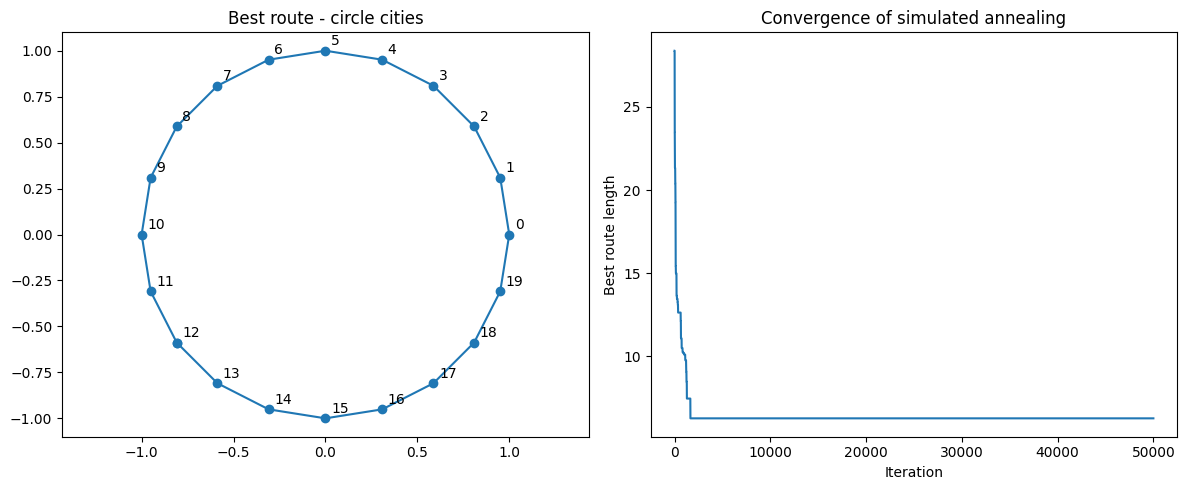

Best route: [12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0, 19, 18, 17, 16, 15, 14, 13]
Best cost: 6.2574
Circle order cost: 6.2574


In [39]:
np.random.seed(42)
num_cities = 20

angles_tsp = [2 * np.pi * i / num_cities for i in range(num_cities)]
city_coords = [[np.cos(a), np.sin(a)] for a in angles_tsp]

def tour_length(coords, route):
    dist = 0.0
    for i in range(len(route)):
        a = coords[route[i]]
        b = coords[route[(i + 1) % len(route)]]
        dist += ((a[0] - b[0])**2 + (a[1] - b[1])**2)**0.5
    return dist

current_route = list(range(num_cities))
np.random.shuffle(current_route)
best_route_tsp = current_route[:]
best_length = tour_length(city_coords, best_route_tsp)
history_tsp = []

for iteration in range(50000):
    i_sw = int(np.random.random() * num_cities)
    j_sw = int(np.random.random() * num_cities)

    while j_sw == i_sw:
        j_sw = int(np.random.random() * num_cities)

    candidate = current_route[:]
    candidate[i_sw], candidate[j_sw] = candidate[j_sw], candidate[i_sw]
    cur_len = tour_length(city_coords, current_route)
    new_len = tour_length(city_coords, candidate)
    temp = 2 / (1 + iteration)**0.5
    delta = new_len - cur_len

    if delta <= 0 or np.random.random() < np.exp(-delta / temp):
        current_route = candidate[:]

    if tour_length(city_coords, current_route) < best_length:
        best_route_tsp = current_route[:]
        best_length = tour_length(city_coords, best_route_tsp)

    history_tsp.append(best_length)

closed_tsp = best_route_tsp + [best_route_tsp[0]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot([city_coords[i][0] for i in closed_tsp], [city_coords[i][1] for i in closed_tsp], "o-")
for i in range(num_cities):
    ax1.text(city_coords[i][0] + 0.03, city_coords[i][1] + 0.03, str(i))
ax1.axis("equal")
ax1.set_title("Best route - circle cities")

ax2.plot(history_tsp)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Best route length")
ax2.set_title("Convergence of simulated annealing")

plt.tight_layout()
plt.show()

print("Best route:", best_route_tsp)
print("Best cost:", round(best_length, 4))
print("Circle order cost:", round(tour_length(city_coords, list(range(num_cities))), 4))

### **Task 2**

In [40]:
np.random.seed(42)

cost_mat = np.loadtxt("cost.csv", delimiter=",")
n_mat = len(cost_mat)

def matrix_tour_cost(mat, route):
    return sum(mat[route[i]][route[(i + 1) % len(route)]] for i in range(len(route)))

route_mat = list(range(n_mat))
np.random.shuffle(route_mat)
best_mat_route = route_mat[:]
best_mat_cost = matrix_tour_cost(cost_mat, best_mat_route)

for iteration in range(50000):
    i_m = int(np.random.random() * n_mat)
    j_m = int(np.random.random() * n_mat)

    while j_m == i_m:
        j_m = int(np.random.random() * n_mat)

    candidate_m = route_mat[:]
    candidate_m[i_m], candidate_m[j_m] = candidate_m[j_m], candidate_m[i_m]
    cur_c = matrix_tour_cost(cost_mat, route_mat)
    new_c = matrix_tour_cost(cost_mat, candidate_m)
    temp_m = 10 / (1 + iteration)**0.5
    delta_m = new_c - cur_c

    if delta_m <= 0 or np.random.random() < np.exp(-delta_m / temp_m):
        route_mat = candidate_m[:]

    if matrix_tour_cost(cost_mat, route_mat) < best_mat_cost:
        best_mat_route = route_mat[:]
        best_mat_cost = matrix_tour_cost(cost_mat, best_mat_route)

print("Best route:", best_mat_route)
print("Best cost:", round(best_mat_cost, 1))

Best route: [12, 0, 3, 18, 14, 2, 10, 19, 6, 17, 16, 9, 15, 7, 4, 11, 5, 13, 8, 1]
Best cost: 1548.0


# **Exercise 8 - Day 7**

### **Task 1 - Book Exercise 13**

##### **A**

In [41]:
sample_data_13 = [56, 101, 78, 67, 93, 87, 64, 72, 80, 69]
n_13 = len(sample_data_13)
a_13 = -5
b_13 = 5
B_13 = 10000

s_mean_13 = sum(sample_data_13) / n_13
np.random.seed(42)

boot_diffs_13 = []

for _ in range(B_13):
    boot_s = [sample_data_13[int(np.random.random() * n_13)] for _ in range(n_13)]
    boot_diffs_13.append(sum(boot_s) / n_13 - s_mean_13)

p_hat_13 = sum(1 for d in boot_diffs_13 if a_13 < d < b_13) / B_13

##### **B**

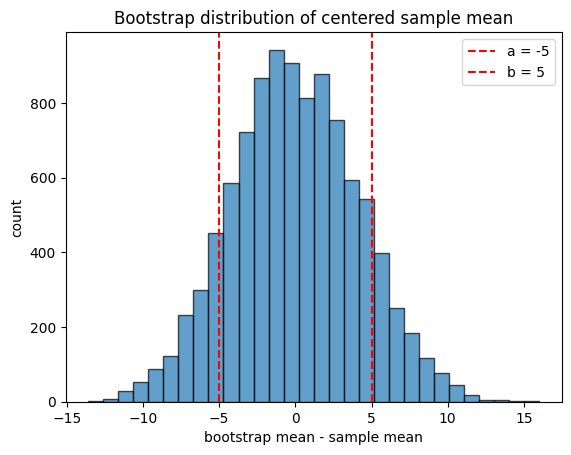

Sample mean: 76.7
Bootstrap estimate of p (Task a): 0.7592
Bootstrap estimate of p (Task b): 0.7622


In [42]:
boot_centered = []

for _ in range(B_13):
    resampled = [sample_data_13[int(np.random.random() * n_13)] for _ in range(n_13)]
    boot_centered.append(sum(resampled) / n_13 - s_mean_13)

p_est_13 = sum(1 for d in boot_centered if a_13 < d < b_13) / B_13

plt.hist(boot_centered, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(a_13, color="red", linestyle="--", label="a = -5")
plt.axvline(b_13, color="red", linestyle="--", label="b = 5")
plt.xlabel("bootstrap mean - sample mean")
plt.ylabel("count")
plt.title("Bootstrap distribution of centered sample mean")
plt.legend()
plt.show()

print("Sample mean:", round(s_mean_13, 4))
print("Bootstrap estimate of p (Task a):", round(p_hat_13, 4))
print("Bootstrap estimate of p (Task b):", round(p_est_13, 4))

### **Task 2 - Book Exercise 15**

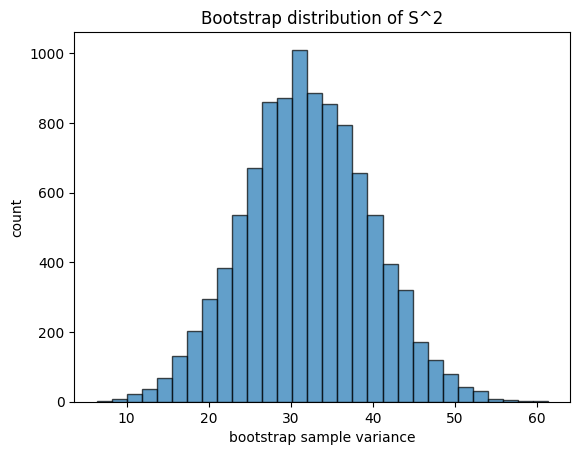

Observed sample variance S^2: 34.3143
Bootstrap estimate of Var(S^2): 58.1795


In [43]:
np.random.seed(42)
sample_data_15 = [5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8]
n_15 = len(sample_data_15)
B_15 = 10000

boot_vars_15 = []

for _ in range(B_15):
    bs = [sample_data_15[int(np.random.random() * n_15)] for _ in range(n_15)]
    bm = sum(bs) / n_15
    bv = sum((x - bm)**2 for x in bs) / (n_15 - 1)
    boot_vars_15.append(bv)

mean_bv = sum(boot_vars_15) / B_15
var_of_s2 = sum((v - mean_bv)**2 for v in boot_vars_15) / (B_15 - 1)

s_mean_15 = sum(sample_data_15) / n_15
s2_obs = sum((x - s_mean_15)**2 for x in sample_data_15) / (n_15 - 1)

plt.hist(boot_vars_15, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("bootstrap sample variance")
plt.ylabel("count")
plt.title("Bootstrap distribution of S^2")
plt.show()

print("Observed sample variance S^2:", round(s2_obs, 4))
print("Bootstrap estimate of Var(S^2):", round(var_of_s2, 4))

### **Task 3**

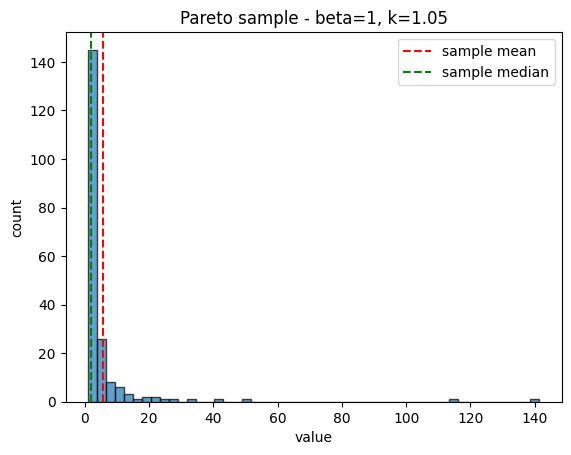

Sample mean: 5.4722
Sample median: 1.9556
Bootstrap variance of the mean:   0.8694
Bootstrap variance of the median: 0.0515
The median is more precise than the mean


In [44]:
np.random.seed(42)
beta_p = 1
shape_p = 1.05
n_p = 200
B_p = 100

pareto_data = [beta_p * np.random.random()**(-1.0 / shape_p) for _ in range(n_p)]
sorted_p = sorted(pareto_data)
s_median_p = sorted_p[n_p // 2] if n_p % 2 == 1 else (sorted_p[n_p // 2 - 1] + sorted_p[n_p // 2]) / 2
s_mean_p = sum(pareto_data) / n_p

boot_med_p = []
boot_mean_p = []

for _ in range(B_p):
    bs_p = [pareto_data[int(np.random.random() * n_p)] for _ in range(n_p)]
    bs_sorted = sorted(bs_p)
    bmed = bs_sorted[n_p // 2] if n_p % 2 == 1 else (bs_sorted[n_p // 2 - 1] + bs_sorted[n_p // 2]) / 2
    boot_med_p.append(bmed)
    boot_mean_p.append(sum(bs_p) / n_p)

mu_mean = sum(boot_mean_p) / B_p
mu_med = sum(boot_med_p) / B_p
var_mean_p = sum((x - mu_mean)**2 for x in boot_mean_p) / (B_p - 1)
var_med_p = sum((x - mu_med)**2 for x in boot_med_p) / (B_p - 1)

plt.hist(pareto_data, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(s_mean_p, color="red", linestyle="--", label="sample mean")
plt.axvline(s_median_p, color="green", linestyle="--", label="sample median")
plt.xlabel("value")
plt.ylabel("count")
plt.title("Pareto sample - beta=1, k=1.05")
plt.legend()
plt.show()

print("Sample mean:", round(s_mean_p, 4))
print("Sample median:", round(s_median_p, 4))
print("Bootstrap variance of the mean:  ", round(var_mean_p, 4))
print("Bootstrap variance of the median:", round(var_med_p, 4))
print("The median is more precise than the mean" if var_med_p < var_mean_p else "The mean is more precise than the median")